# Notebook 01 - Corridor Incident: Kinematics Model

Author: Stellars Henson<br>
Approach: a kinematics model of the contested corridor incident - the alleged three-second, two-phase movement of a body against the elevator door.  The model reconstructs Victoria's centre-of-mass trajectory: phase 1, the approach to the door; the impact, treated as a decoupled singularity; phase 2, the return.

The modelling lives in the `henryk_simulations.corridor.choreography` library; this notebook is a thin client over it - it presents the linear prototype, the configuration, the rotation duration constraint, the free parameters and constraints, and the solved kinematics envelope.

## Model decisions

- **One body.**  This is a kinematics study of Victoria's centre of mass; Andrew's motion is not modelled here.
- **Structural acceleration.**  The tangential acceleration is a smooth trapezoid - a start ramp (the "give"), a plateau, a release ramp (the "let-go"), and a coast - parametrised by its durations, not by spline knots.  The give and let-go are literature-pinned from the rate-of-force-development band.
- **Decoupled impact singularity.**  The impact is a separate impulsive event resolved on its own millisecond timeline; on the 3 s axis it is a point - a velocity step from the closing velocity to zero.
- **Kinematics envelope.**  The release standoff - where the body leaves the actor's hands - is swept over its two physical extremes: propelled to the door (no coast), and released two torso depths back to coast in.  The two solutions bracket the motion.
- **Forces are downstream.**  The total force at the impact combines an impact-force component (the collision, body compression) with an acceleration-force component (Victoria's own push).  Their proportion is a hyperparameter applied in the force notebook, not here.

## Outputs

- `reports/figures/01-linear-reference-model.png` - the linear prototype skeleton
- `reports/figures/01-path-curve.png` - the curved centre-of-mass path
- `reports/figures/01-phase2-rotation.png` - the phase-2 rotation duration constraint
- `reports/figures/01-kinematics-envelope.png` - the full-choreography kinematics envelope

In [1]:
# Imports
from __future__ import annotations

import dataclasses
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# Project library - the choreography modelling lives in the corridor submodule
from henryk_simulations.corridor import (
    ChoreographyConfig,
    constraints,
    default_scenario,
    free_parameters,
    impact_singularity,
    solve_choreography,
    solve_envelope,
)
from henryk_simulations.corridor.choreography import YIELD_FACTORS
from henryk_simulations.corridor.plots import plot_corridor_overhead

%load_ext autoreload
%autoreload 2

console = Console()
sns.set_theme(style="whitegrid", context="notebook")

2026-05-18 08:32:58.013 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
SEED = 42
np.random.seed(SEED)

## The Scene

A corridor.  Two doors face each other - apartment door on the north wall, elevator door on the south.  The gap between them is 2 m.  Side walls sit 1.5 m apart.  The doors are 2.1 m tall.

Two bodies.  Andrew - 90 kg, 1.80 m tall.  Victoria - 70 kg, 1.68 m tall.

### The Phases

The claim is three moves, 3 s in total.

1. **Pull** - Andrew backs toward the elevator.  Victoria comes with him.  Her centre of mass covers 1.5 m of the 2 m run.
2. **Swap and throw** - the two trade places.  Victoria's back meets the elevator door.  She turns 180 degrees.
3. **Swap back** - they trade places again.  Andrew turns 180 degrees.  Victoria turns 180 degrees.

This notebook models one body - Victoria's centre of mass.  Phase 1 is the approach to the door.  The impact is a separate event.  Phase 2 is the return.


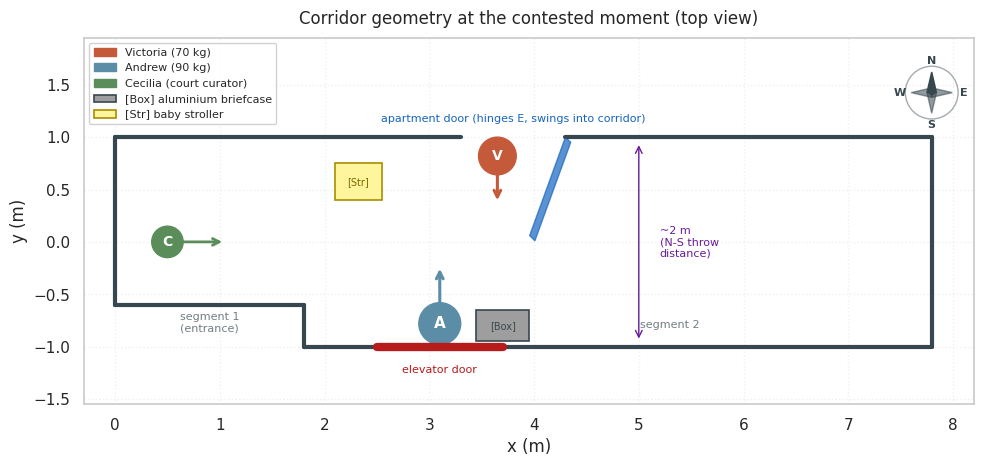

In [3]:
# Corridor overhead geometry - generated from the default scenario
fig_dir = Path("..") / "reports" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
scene = default_scenario()
plot_corridor_overhead(
    scene.geometry, scene.bodies, out_path=fig_dir / "01-corridor-geometry.png"
)
plt.show()


In [4]:
# Modelled phases of the movement - the two-phase model and its testimonial basis
phases = Table(title="[bold]Modelled phases of Victoria's movement[/bold]",
               show_header=True, header_style="bold cyan", show_lines=True)
phases.add_column("Phase", style="bold")
phases.add_column("Modelled movement")
phases.add_column("Source")
phases.add_row(
    "Phase 1 - pull",
    "Pull toward the elevator door with a 180-degree half-rotation",
    "Victoria's and Cecilia's testimony - Victoria testified that Andrew "
    "pulled her and threw her at the elevator door; the corridor geometry "
    "constrains Phase 1",
)
phases.add_row(
    "Phase 2 - departure",
    "Departure from the door with a 180-degree half-rotation, repositioning "
    "to face Andrew front-on",
    "Cecilia's testimony: Victoria began screaming on seeing Cecilia, then "
    "stood against Andrew facing him, with Andrew having his back against "
    "the elevator door",
)
console.print(phases)


                                      Modelled phases of Victoria's movement                                       
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Phase               ┃ Modelled movement                           ┃ Source                                      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Phase 1 - pull      │ Pull toward the elevator door with a        │ Victoria's and Cecilia's testimony -        │
│                     │ 180-degree half-rotation                    │ Victoria testified that Andrew pulled her   │
│                     │                                             │ and threw her at the elevator door; the     │
│                     │                                             │ corridor geometry constrains Phase 1        │
├─────────────────────┼─────────────────────────────────────────────┼─────────────────────────────────────────────┤
│ Phase 2 - departure │ Departure from the door with a 180-degree   │ Cecilia's testimony: Victoria began         │
│                     │ half-rotation, repositioning to face Andrew │ screaming on seeing Cecilia, then stood     │
│                     │ front-on                                    │ against Andrew facing him, with Andrew      │
│                     │                                             │ having his back against the elevator door   │
└─────────────────────┴─────────────────────────────────────────────┴─────────────────────────────────────────────┘

## Kinematics Linear Prototype

Before the smooth model, the problem is grounded with the **kinematics linear prototype** - a piecewise-linear acceleration model, the idealised skeleton that the structural trapezoid refines.  In this reference model the acceleration is a sequence of straight-line ramps and plateaus; integrating once gives a piecewise-quadratic velocity and again a piecewise-cubic position.  The diagram below shows all three.  It is **symbolic**.  The impact is a decoupled singularity - the deceleration is physically about ten times deeper than `a_max` - so the acceleration panel marks it only as a shaded **singularity zone** rather than drawing the off-chart spike, keeping the choreography levels legible.  The segment areas are balanced, so velocity returns to zero at the start, at the foot of the impact spike, and at the end.

**Phase 1** (pull to the door):

1. **Start jerk / give** - acceleration ramps linearly from `a = 0` up to `a_max`
2. **Constant acceleration** - plateau at `a_max`
3. **Release** - acceleration ramps `a_max -> 0` over its yield time
4. **Coast** - `a = 0`, the body travels at constant speed
5. **Impact** - a deceleration spike `0 -> a_imp -> 0`, ending when `v = 0`; this spike is the **decoupled singularity**, resolved separately on its own millisecond timeline

**Phase 2** (return from the door):

1. **Reverse jerk** - acceleration ramps from `(a = 0, v = 0)` to the reverse-direction acceleration `a_rev`
2. **Deceleration** - acceleration ramps from `a_rev` through zero to the brake level `a_brk`, then back to `0`, bringing the body to rest (`a = 0, v = 0`)

The ramp corners in this model are sharp - infinite jerk at every breakpoint.  The structural model below replaces each sharp corner with a C2-smooth (smootherstep) transition - the give, plateau, let-go and coast become the structural durations.  The linear prototype is the reference skeleton the smooth model is built on.

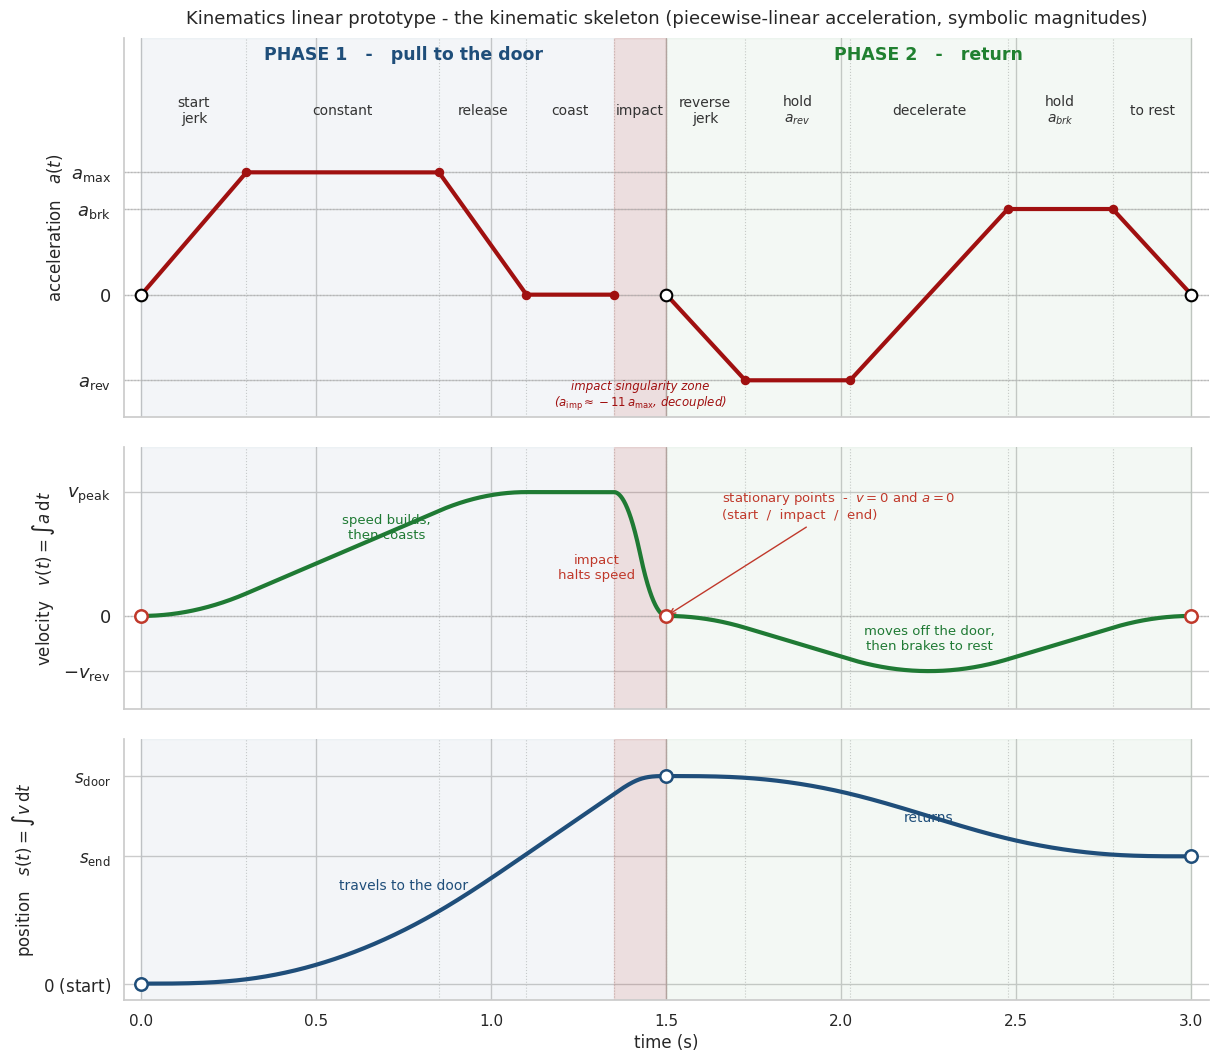

Linear reference model: acceleration (piecewise-linear) integrates to velocity (piecewise-quadratic) and to position (piecewise-cubic). Vertical guides link the same instant across all three panels. Areas balanced so v=0 at the three stationary points. The sharp corners are infinite-jerk - the spline QP below smooths them to C2.


In [5]:
# Linear reference model - piecewise-linear acceleration, SYMBOLIC schematic.
# Areas balanced so velocity returns to zero at every stationary point
# (start, impact, end). Acceleration integrates once to velocity, again to
# position. The impact spike a_imp is ~11x deeper than a_max and is drawn
# off-scale so the choreography levels stay legible. Structure only.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path as _Path
_FIG_DIR = _Path("..") / "reports" / "figures"
_FIG_DIR.mkdir(parents=True, exist_ok=True)

# symbolic acceleration levels (illustrative magnitudes)
a_max = 1.00                     # phase-1 peak choreography acceleration
a_rev = -0.70                    # phase-2 reverse-direction acceleration
a_brk = -a_rev                   # phase-2 brake (mirrors a_rev -> phase-2 v balances)

# piecewise-linear acceleration breakpoints (time, accel)
bp_t = [0.00, 0.30, 0.85, 1.10, 1.35, 1.425, 1.50,
        1.725, 2.025, 2.475, 2.775, 3.00]
A_accel = 0.5 * 0.30 * a_max + 0.55 * a_max + 0.5 * 0.25 * a_max
a_imp = -A_accel / (0.5 * 0.15)   # impact depth that cancels the phase-1 accel area
bp_a = [0.0, a_max, a_max, 0.0, 0.0, a_imp, 0.0,
        a_rev, a_rev, a_brk, a_brk, 0.0]

# integrate: a -> v -> s
tg = np.linspace(0, 3.0, 6000)
a_lin = np.interp(tg, bp_t, bp_a)
v_lin = np.concatenate([[0], np.cumsum((a_lin[1:] + a_lin[:-1]) / 2 * np.diff(tg))])
s_lin = np.concatenate([[0], np.cumsum((v_lin[1:] + v_lin[:-1]) / 2 * np.diff(tg))])
t_imp = 1.5
v_imp, s_imp = np.interp(t_imp, tg, v_lin), np.interp(t_imp, tg, s_lin)
v_peak, v_min, s_end = v_lin.max(), v_lin.min(), s_lin[-1]

# segment dividers + labels
seg_bounds = [0.30, 0.85, 1.10, 1.35, 1.50, 1.725, 2.025, 2.475, 2.775]
segments = [(0.15, "start\njerk"), (0.575, "constant"), (0.975, "release"),
            (1.225, "coast"), (1.425, "impact"), (1.61, "reverse\njerk"),
            (1.875, "hold\n$a_{rev}$"), (2.25, "decelerate"),
            (2.625, "hold\n$a_{brk}$"), (2.89, "to rest")]

fig = plt.figure(figsize=(14, 12.5))
gs = GridSpec(3, 1, height_ratios=[1.45, 1.0, 1.0], hspace=0.10)
ax_a = fig.add_subplot(gs[0])
ax_v = fig.add_subplot(gs[1], sharex=ax_a)
ax_s = fig.add_subplot(gs[2], sharex=ax_a)

# shared backdrop: phase tints + segment dividers + impact line
for ax in (ax_a, ax_v, ax_s):
    ax.axvspan(0.0, 1.5, color="#1f4e7a", alpha=0.05)
    ax.axvspan(1.5, 3.0, color="#208030", alpha=0.05)
    for xb in seg_bounds:
        ax.axvline(xb, color="#cfcfcf", ls=":", lw=0.8, zorder=0)
    ax.axvspan(1.35, 1.50, color="#c0392b", alpha=0.12, zorder=1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(-0.05, 3.05)

# ----- ACCELERATION -----
for lvl in (a_max, a_brk, 0.0, a_rev):
    ax_a.axhline(lvl, color="#b0b0b0", ls=":", lw=0.9, alpha=0.8)
# impact singularity masked off the curve - shown as a zone, not an off-chart spike
a_disp = np.where((tg >= 1.35) & (tg <= 1.50), np.nan, a_lin)
ax_a.plot(tg, a_disp, color="#a01010", lw=3.0, solid_joinstyle="round", zorder=4)
_knot = [(t, a) for t, a in zip(bp_t, bp_a) if a > a_rev - 0.30]
ax_a.scatter([t for t, _ in _knot], [a for _, a in _knot],
             color="#a01010", s=34, zorder=5)   # knots
ax_a.scatter([0, 1.5, 3.0], [0, 0, 0], facecolor="white", edgecolor="black",
             s=70, lw=1.5, zorder=6)
ax_a.set_yticks([a_rev, 0.0, a_brk, a_max])
ax_a.set_yticklabels([r"$a_\mathrm{rev}$", "$0$", r"$a_\mathrm{brk}$",
                      r"$a_\mathrm{max}$"], fontsize=13)
ax_a.set_ylim(a_rev - 0.30, a_max * 2.10)
ax_a.set_ylabel("acceleration   $a(t)$", fontsize=12)
# segment labels in a band above the curve
for tx, lab in segments:
    ax_a.text(tx, a_max * 1.50, lab, ha="center", va="center", fontsize=10,
              color="#333333")
# phase headers
ax_a.text(0.75, a_max * 1.92, "PHASE 1   -   pull to the door", ha="center",
          fontsize=12.5, fontweight="bold", color="#1f4e7a")
ax_a.text(2.25, a_max * 1.92, "PHASE 2   -   return", ha="center",
          fontsize=12.5, fontweight="bold", color="#208030")
# impact singularity zone - the spike is decoupled, not drawn
ax_a.text(1.425, a_rev - 0.13, "impact singularity zone\n"
          r"($a_\mathrm{imp}\approx-11\,a_\mathrm{max}$, decoupled)",
          ha="center", va="center", fontsize=8.5, color="#a01010", style="italic")
ax_a.set_title("Kinematics linear prototype - the kinematic skeleton "
               "(piecewise-linear acceleration, symbolic magnitudes)",
               fontsize=13, pad=10)

# ----- VELOCITY -----
ax_v.axhline(0.0, color="#b0b0b0", ls=":", lw=0.9, alpha=0.8)
ax_v.plot(tg, v_lin, color="#1f7a34", lw=3.0, zorder=4)
ax_v.scatter([0, t_imp, 3.0], [0, v_imp, 0], facecolor="white",
             edgecolor="#c0392b", s=80, lw=1.8, zorder=6)
ax_v.set_yticks([v_min, 0.0, v_peak])
ax_v.set_yticklabels([r"$-v_\mathrm{rev}$", "$0$", r"$v_\mathrm{peak}$"],
                     fontsize=13)
ax_v.set_ylabel(r"velocity   $v(t)=\int a\,\mathrm{d}t$", fontsize=12)
ax_v.set_ylim(v_min - 0.25, v_peak + 0.30)
ax_v.text(0.70, v_peak * 0.62, "speed builds,\nthen coasts", ha="center",
          fontsize=9.5, color="#1f7a34")
ax_v.text(1.30, v_peak * 0.30, "impact\nhalts speed", ha="center", fontsize=9.5,
          color="#c0392b")
ax_v.text(2.25, v_min * 0.62, "moves off the door,\nthen brakes to rest",
          ha="center", fontsize=9.5, color="#1f7a34")
ax_v.annotate("stationary points  -  $v=0$ and $a=0$\n(start  /  impact  /  end)",
              xy=(t_imp, v_imp), xytext=(1.66, v_peak * 0.78), fontsize=9.5,
              color="#c0392b", arrowprops=dict(arrowstyle="->", color="#c0392b"))

# ----- POSITION -----
ax_s.plot(tg, s_lin, color="#1f4e7a", lw=3.0, zorder=4)
ax_s.scatter([0, t_imp, 3.0], [0, s_imp, s_end], facecolor="white",
             edgecolor="#1f4e7a", s=80, lw=1.8, zorder=6)
ax_s.set_yticks([0.0, s_end, s_imp])
ax_s.set_yticklabels(["$0$ (start)", r"$s_\mathrm{end}$", r"$s_\mathrm{door}$"],
                     fontsize=12)
ax_s.set_ylabel(r"position   $s(t)=\int v\,\mathrm{d}t$", fontsize=12)
ax_s.set_ylim(-0.08 * s_imp, s_imp * 1.18)
ax_s.set_xlabel("time (s)", fontsize=12)
ax_s.text(0.75, s_imp * 0.45, "travels to the door", ha="center", fontsize=10,
          color="#1f4e7a")
ax_s.text(2.25, s_imp * 0.78, "returns", ha="center", fontsize=10,
          color="#1f4e7a")

for ax in (ax_a, ax_v):
    plt.setp(ax.get_xticklabels(), visible=False)

fig.savefig(_FIG_DIR / "01-linear-reference-model.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Linear reference model: acceleration (piecewise-linear) integrates to "
      "velocity (piecewise-quadratic) and to position (piecewise-cubic). "
      "Vertical guides link the same instant across all three panels. Areas "
      "balanced so v=0 at the three stationary points. The sharp corners are "
      "infinite-jerk - the spline QP below smooths them to C2.")

## Configuration

`ChoreographyConfig` from the corridor library is the **single configuration object** for this notebook - corridor geometry, body parameters, the literature bands, and the locked timeline.  Every section below reads from it; the notebook holds no separate config of its own.

In [6]:
CHOREO = ChoreographyConfig()
FIG_DIR = Path("..") / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg_tbl = Table(show_header=False, box=None, padding=(0, 2))
cfg_tbl.add_column("field", style="bold cyan")
cfg_tbl.add_column("value")
for f in dataclasses.fields(CHOREO):
    cfg_tbl.add_row(f.name, f"[white]{getattr(CHOREO, f.name)}[/white]")
console.print(Panel(cfg_tbl, title="[bold green]ChoreographyConfig[/bold green]",
                    border_style="green"))

╭────────────────────────────────────────────── ChoreographyConfig ───────────────────────────────────────────────╮
│   total_time              3.0                                                                                   │
│   phase1_duration         1.5                                                                                   │
│   phase2_duration         1.5                                                                                   │
│   arc_length              2.0                                                                                   │
│   lateral_offset          0.25                                                                                  │
│   return_translation      0.5                                                                                   │
│   rotation                3.141592653589793                                                                     │
│   body_mass               70.0                                                                                  │
│   yaw_inertia             1.4                                                                                   │
│   body_compression        0.03                                                                                  │
│   body_compression_min    0.02                                                                                  │
│   body_compression_max    0.05                                                                                  │
│   body_thickness          0.28                                                                                  │
│   t_give                  0.2                                                                                   │
│   t_letgo                 0.12                                                                                  │
│   ramp_min                0.05                                                                                  │
│   ramp_max                0.25                                                                                  │
│   a_max_ceiling           5.5                                                                                   │
│   a_max_typical           3.0                                                                                   │
│   jerk_ceiling            50.0                                                                                  │
│   n_eval                  2000                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Phase-2 Duration Constraint - the 180 Degree Rotation

Before the full kinematics study, one constraint on phase 2 can be settled on its own.  Phase 2 contains a **180 degree yaw rotation**, and rotating a human body takes time - that time is a floor on the phase-2 duration, fixed before any trajectory is solved.

Treat the body, turning about its vertical axis, as a rigid body with a yaw **moment of inertia** $I$.  Plagenhoef, Evans & Abdelnour (1983) give the whole-body yaw moment of inertia about the centre of mass as about 1.5 kg m$^2$ for a 75 kg adult; scaled to a 70 kg body this notebook assumes $I = 1.4$ kg m$^2$.

**Two separate turns, not one.**  Phase 1 rotates the body 180 degrees to strike the door back-first; phase 2 rotates it another 180 degrees to the front-first configuration Cecilia described.  The body's rotation halts at the impact - the collision with the rigid door arrests the spin just as it arrests the translation, and a clean back-first impact requires the turn to be already complete ($\omega\approx 0$) at contact.  So each phase is its own rest-to-rest turn, accelerating from $\omega=0$, building angular momentum $L=I\,\omega$ under a torque $\tau=I\,\alpha$, then decelerating back to $\omega=0$.

For a symmetric accelerate-decelerate the peak yaw rate is $\omega_\text{peak}=2\,\Delta\theta/t_2=2\pi/t_2$, so a cap on $\omega_\text{peak}$ becomes a floor on $t_2$.  Hodgson, Lewis & Drury (2008) measured the peak yaw rate of a voluntary 180 degree standing pivot at 3.5 rad/s (SD 1.0):

- **population** rate 3.5 rad/s  ->  $t_2 \ge 2\pi/3.5 = 1.80$ s
- **elite** rate 5.5 rad/s (mean + 2 SD)  ->  $t_2 \ge 2\pi/5.5 = 1.14$ s

The simulation **locks the phase-2 duration at the midpoint of these two floors**, $t_2 \approx 1.47$ s, and adopts it as the lower-bound constraint - neither the generous elite figure nor the strict population figure.  Phase 1 then takes the remaining $t_1 = 3 - t_2 \approx 1.53$ s.  Under the yaw-rate cap a single continuous 360 degree turn would need the same total time; the two separate turns differ only in demanding roughly twice the angular acceleration, since each half has half the time to spin up.

This is also why the kinematics study **bundles the rotation with the translation** rather than sequencing them.  With the two 180 degree turns alone consuming 2.94 s of the 3 s budget, a sequential rotate-then-translate timeline cannot fit - the rotations would leave almost nothing for the 2 m pull and the 0.5 m return.  The timeline holds only if each phase performs its turn and its translation **concurrently**, over the same interval.  Bundling them is the most charitable reading consistent with the lower-bound estimation; sequencing them would put the choreography over budget before the translation began.

**References**: Plagenhoef, Evans & Abdelnour (1983) - whole-body yaw moment of inertia; Hodgson, Lewis & Drury (2008) - peak yaw rate of a voluntary 180 degree standing pivot.  Both are archived under `references/literature/`.

Assumed human-body yaw moment of inertia: I = 1.4 kg m^2 (Plagenhoef et al. 1983, scaled to 70 kg)

Phase-2 180 deg rotation, rest-to-rest - yaw-rate duration floors (Hodgson et al. 2008):

population rate 3.5 rad/s  ->  t2 >= 1.80 s

elite rate      5.5 rad/s  ->  t2 >= 1.14 s

LOCKED phase-2 duration  t2 = 1.469 s (midpoint)  ->  phase-1  t1 = 1.531 s

at the lock: yaw rate 4.28 rad/s, accel 5.82 rad/s^2, torque 8.2 N m, angular momentum 5.99 kg m^2/s, rotational 
KE 12.8 J

phase 1 carries the same 180 deg turn: the two rotations alone consume 2.94 s of the 3.0 s budget at the locked 
rate (3.59 s at the population rate) - leaving almost nothing for the translation.

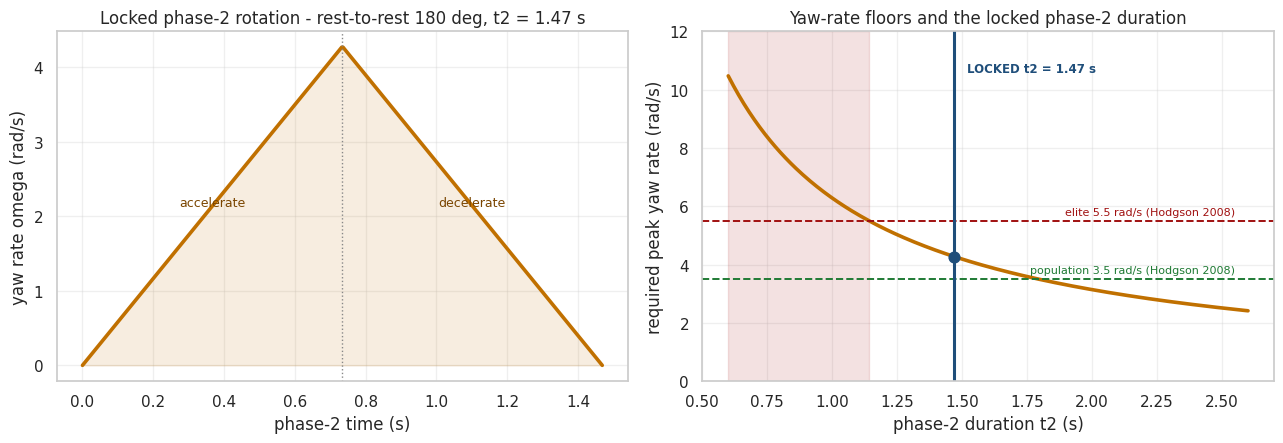

In [7]:
# Phase-2 duration constraint from the 180 deg yaw rotation.
# The body is assumed a rigid body with a human yaw moment of inertia.
I_YAW = CHOREO.yaw_inertia  # kg m^2, Plagenhoef 1983 scaled to 70 kg
DTHETA2 = CHOREO.rotation  # rad (180 deg yaw turn)
T_TOTAL = CHOREO.total_time
# Peak yaw rate of a voluntary 180 deg standing pivot (Hodgson, Lewis &
# Drury 2008): mean 3.5 rad/s, SD 1.0. Population = mean; elite = mean + 2 SD.
OMEGA_POPULATION = 3.5
OMEGA_ELITE = 5.5


def omega_peak_rotation(t2, dtheta=DTHETA2):
    """Peak yaw rate of a rest-to-rest rotation of dtheta in time t2.
    Symmetric accelerate-decelerate: dtheta = omega_peak * t2 / 2."""
    return 2.0 * dtheta / t2


# duration floors: omega_peak <= omega_max  ->  t2 >= 2*dtheta/omega_max
t2_floor_population = 2.0 * DTHETA2 / OMEGA_POPULATION
t2_floor_elite = 2.0 * DTHETA2 / OMEGA_ELITE
# LOCK the phase-2 duration at the midpoint of the two floors - the
# lower-bound constraint adopted for the simulation.
t2_lock = 0.5 * (t2_floor_population + t2_floor_elite)
t1_lock = T_TOTAL - t2_lock

# rotational dynamics at the locked phase-2 duration
omega_lock = omega_peak_rotation(t2_lock)
alpha_lock = 4.0 * DTHETA2 / t2_lock**2
torque_lock = I_YAW * alpha_lock
L_lock = I_YAW * omega_lock
KE_rot = 0.5 * I_YAW * omega_lock**2

console.print(f"Assumed human-body yaw moment of inertia: I = {I_YAW} kg m^2 "
              f"(Plagenhoef et al. 1983, scaled to 70 kg)")
console.print(f"Phase-2 180 deg rotation, rest-to-rest - yaw-rate duration floors "
              f"(Hodgson et al. 2008):")
console.print(f"  population rate {OMEGA_POPULATION} rad/s  ->  t2 >= "
              f"{t2_floor_population:.2f} s")
console.print(f"  elite rate      {OMEGA_ELITE} rad/s  ->  t2 >= "
              f"{t2_floor_elite:.2f} s")
console.print(f"  [bold]LOCKED phase-2 duration  t2 = {t2_lock:.3f} s[/bold] "
              f"(midpoint)  ->  phase-1  t1 = {t1_lock:.3f} s")
console.print(f"  at the lock: yaw rate {omega_lock:.2f} rad/s, accel "
              f"{alpha_lock:.2f} rad/s^2, torque {torque_lock:.1f} N m, "
              f"angular momentum {L_lock:.2f} kg m^2/s, rotational KE "
              f"{KE_rot:.1f} J")
console.print(f"  [yellow]phase 1 carries the same 180 deg turn: the two "
              f"rotations alone consume {2*t2_lock:.2f} s of the {T_TOTAL:.1f} s "
              f"budget at the locked rate ({2*t2_floor_population:.2f} s at the "
              f"population rate) - leaving almost nothing for the translation."
              f"[/yellow]")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
# (a) the rest-to-rest turn at the locked phase-2 duration
tt = np.linspace(0, t2_lock, 400)
omega_t = np.where(tt <= t2_lock / 2, alpha_lock * tt, alpha_lock * (t2_lock - tt))
axes[0].plot(tt, omega_t, color="#c07000", lw=2.6)
axes[0].fill_between(tt, 0, omega_t, color="#c07000", alpha=0.12)
axes[0].axvline(t2_lock / 2, color="#888888", ls=":", lw=1)
axes[0].text(t2_lock * 0.25, omega_lock * 0.5, "accelerate", ha="center",
             fontsize=9, color="#7a4500")
axes[0].text(t2_lock * 0.75, omega_lock * 0.5, "decelerate", ha="center",
             fontsize=9, color="#7a4500")
axes[0].set_xlabel("phase-2 time (s)")
axes[0].set_ylabel("yaw rate omega (rad/s)")
axes[0].set_title(f"Locked phase-2 rotation - rest-to-rest 180 deg, "
                  f"t2 = {t2_lock:.2f} s")
axes[0].grid(True, alpha=0.3)
# (b) required peak yaw rate vs phase-2 duration, with the floors and the lock
t2v = np.linspace(0.6, 2.6, 300)
axes[1].plot(t2v, omega_peak_rotation(t2v), color="#c07000", lw=2.6)
axes[1].axhline(OMEGA_ELITE, color="#a01010", ls="--", lw=1.4)
axes[1].axhline(OMEGA_POPULATION, color="#1f7a34", ls="--", lw=1.4)
axes[1].axvline(t2_lock, color="#1f4e7a", lw=2.2)
axes[1].scatter([t2_lock], [omega_lock], color="#1f4e7a", s=60, zorder=5)
axes[1].axvspan(t2v[0], t2_floor_elite, color="#a01010", alpha=0.12)
axes[1].text(2.55, OMEGA_ELITE + 0.2, "elite 5.5 rad/s (Hodgson 2008)",
             ha="right", fontsize=8, color="#a01010")
axes[1].text(2.55, OMEGA_POPULATION + 0.2, "population 3.5 rad/s (Hodgson 2008)",
             ha="right", fontsize=8, color="#1f7a34")
axes[1].text(t2_lock + 0.05, 10.6, f"LOCKED t2 = {t2_lock:.2f} s",
             fontsize=8.5, color="#1f4e7a", fontweight="bold")
axes[1].set_xlabel("phase-2 duration t2 (s)")
axes[1].set_ylabel("required peak yaw rate (rad/s)")
axes[1].set_title("Yaw-rate floors and the locked phase-2 duration")
axes[1].set_ylim(0, 12)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01-phase2-rotation.png", dpi=140, bbox_inches="tight")
plt.show()

## Curved CoM Path

Victoria's centre of mass does not travel a straight line - the corridor geometry has a diagonal offset and a body rotating 180 deg sweeps its CoM along a curve.  We model the path as a smooth 2D curve (quadratic Bezier) with **arc length 2.0 m** - the distance the CoM actually travels.

Curved path arc length: 2.000 m  (straight-line 1.919 m)

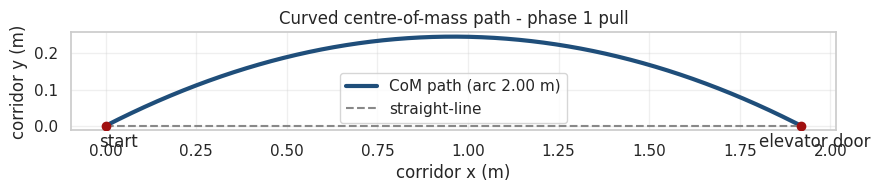

In [8]:
L_arc = CHOREO.arc_length
sag = CHOREO.lateral_offset

P0 = np.array([0.0, 0.0])
P1 = np.array([1.95, 0.0])
Pc = np.array([0.975, 2.0 * sag])

u = np.linspace(0, 1, 4000)
bez = (1-u)[:, None]**2 * P0 + 2*(1-u)[:, None]*u[:, None] * Pc + u[:, None]**2 * P1
seg = np.sqrt(np.sum(np.diff(bez, axis=0)**2, axis=1))
arc = np.concatenate([[0], np.cumsum(seg)])
scale = L_arc / arc[-1]
bez *= scale
arc *= scale

console.print(f"Curved path arc length: {arc[-1]:.3f} m  "
              f"(straight-line {np.linalg.norm(P1-P0)*scale:.3f} m)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bez[:, 0], bez[:, 1], color="#1f4e7a", lw=3, label=f"CoM path (arc {arc[-1]:.2f} m)")
ax.plot([P0[0]*scale, P1[0]*scale], [0, 0], "--", color="#888", label="straight-line")
ax.scatter([P0[0]*scale, P1[0]*scale], [0, 0], color="#a01010", zorder=5)
ax.annotate("start", P0*scale, textcoords="offset points", xytext=(-5, -15))
ax.annotate("elevator door", P1*scale, textcoords="offset points", xytext=(-30, -15))
ax.set_aspect("equal")
ax.set_xlabel("corridor x (m)"); ax.set_ylabel("corridor y (m)")
ax.set_title("Curved centre-of-mass path - phase 1 pull")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01-path-curve.png", dpi=140, bbox_inches="tight")
plt.show()

## Free Parameters and Constraints

The choreography modelling lives in `henryk_simulations.corridor.choreography`; this notebook is a thin client over it.

The tangential acceleration is parametrised by its **structural durations**, not by spline knots.  Phase 1 is a smooth trapezoid: a start ramp - the **give**, `a` rising `0 -> a_max` - then a plateau, then a release ramp - the **let-go**, `a` falling `a_max -> 0` - then a coast.

The re-parametrisation from the quintic-spline predecessor cut the parameter count from 37 spline knots to these few **structural parameters**.  Literature and the scenario then **constrain** each parameter to a permissible range - the **exclusion zones**.  This is the key point: the exclusion zones *bound the search space*, they do **not eliminate** parameters.  The ramps are constrained to the rate-of-force-development band, the peak acceleration to the Mero ceiling, the impact duration to the body-compression range; the release standoff is the envelope variable, swept over its two extremes.

The **constraints** below are of two kinds.  **Equality** constraints are the scenario boundary conditions.  **Inequality** constraints are the exclusion zones - the literature-bounded permissible ranges - each carrying its **source**.

In [9]:
# CHOREO is built in the Configuration section above.
fps = free_parameters(CHOREO)
fp = Table(show_lines=True, title="[bold]Free parameters - each constrained, none eliminated[/bold]",
           show_header=True, header_style="bold cyan")
fp.add_column("Parameter"); fp.add_column("Symbol")
fp.add_column("Permissible range", justify="right")
fp.add_column("Bounded by"); fp.add_column("Unit")
for p in fps:
    fp.add_row(p.name, p.symbol, p.permissible_range, p.bounded_by, p.unit)
console.print(fp)
console.print(f"[bold]{len(fps)} structural parameters[/bold] - the re-parametrisation "
              f"from the quintic-spline predecessor cut the count from 37 spline "
              f"knots to these few. Literature and the scenario then "
              f"[bold]constrain[/bold] each to a permissible range (the exclusion "
              f"zones); this bounds the search space, it does [bold]not[/bold] "
              f"eliminate parameters.")

ct = Table(show_lines=True, title="[bold]Constraints - boundary conditions and exclusion zones[/bold]",
           show_header=True, header_style="bold cyan")
ct.add_column("Constraint"); ct.add_column("Kind")
ct.add_column("Expression"); ct.add_column("Source")
for c in constraints(CHOREO):
    tag = "[green]equality[/]" if c.kind == "equality" else "[yellow]inequality[/]"
    ct.add_row(c.name, tag, c.expression, c.source)
console.print(ct)

                                Free parameters - each constrained, none eliminated                                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Parameter                   ┃ Symbol             ┃       Permissible range ┃ Bounded by                 ┃ Unit  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ start ramp (give)           │ t_give             │                50 - 250 │ RFD exclusion zone         │ ms    │
│                             │                    │                         │ (Maffiuletti 2016, Aagaard │       │
│                             │                    │                         │ 2002)                      │       │
├─────────────────────────────┼────────────────────┼─────────────────────────┼────────────────────────────┼───────┤
│ release ramp (let-go)       │ t_letgo            │                50 - 250 │ RFD exclusion zone         │ ms    │
│                             │                    │                         │ (Maffiuletti 2016, Aagaard │       │
│                             │                    │                         │ 2002)                      │       │
├─────────────────────────────┼────────────────────┼─────────────────────────┼────────────────────────────┼───────┤
│ phase durations             │ t1, t2             │             1.50 / 1.50 │ equal-split hypothesis     │ s     │
├─────────────────────────────┼────────────────────┼─────────────────────────┼────────────────────────────┼───────┤
│ release standoff            │ d_standoff         │                0 - 0.56 │ envelope variable - body   │ m     │
│                             │                    │                         │ geometry                   │       │
├─────────────────────────────┼────────────────────┼─────────────────────────┼────────────────────────────┼───────┤
│ plateau / coast split       │ t_plateau, t_coast │                 see run │ coupled: timeline +        │ s     │
│                             │                    │                         │ distance + standoff        │       │
├─────────────────────────────┼────────────────────┼─────────────────────────┼────────────────────────────┼───────┤
│ peak acceleration           │ a_max              │                  <= 5.5 │ Mero 1992 production limit │ m/s^2 │
├─────────────────────────────┼────────────────────┼─────────────────────────┼────────────────────────────┼───────┤
│ impact-singularity duration │ tau_imp            │ body compression 2-5 cm │ body-compression exclusion │ s     │
│                             │                    │                         │ zone                       │       │
└─────────────────────────────┴────────────────────┴─────────────────────────┴────────────────────────────┴───────┘

7 structural parameters - the re-parametrisation from the quintic-spline predecessor cut the count from 37 spline 
knots to these few. Literature and the scenario then constrain each to a permissible range (the exclusion zones); 
this bounds the search space, it does not eliminate parameters.

                               Constraints - boundary conditions and exclusion zones                               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Constraint                  ┃ Kind       ┃ Expression                       ┃ Source                            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ release standoff (coasting) │ equality   │ with-coast solution: body        │ body geometry - the actor cannot  │
│                             │            │ released 2x body thickness (56   │ release at the door; two torso    │
│                             │            │ cm) before the door              │ depths of standoff (torso depth   │
│                             │            │                                  │ ~28 cm)                           │
├─────────────────────────────┼────────────┼──────────────────────────────────┼───────────────────────────────────┤
│ give ramp within RFD band   │ inequality │ 50 <= t_give <= 250 ms           │ Maffiuletti et al. 2016; Aagaard  │
│                             │            │                                  │ et al. 2002 - rate of force       │
│                             │            │                                  │ development                       │
├─────────────────────────────┼────────────┼──────────────────────────────────┼───────────────────────────────────┤
│ let-go ramp within RFD band │ inequality │ 50 <= t_letgo <= 250 ms          │ Maffiuletti et al. 2016; Aagaard  │
│                             │            │                                  │ et al. 2002 - rate of force       │
│                             │            │                                  │ development                       │
├─────────────────────────────┼────────────┼──────────────────────────────────┼───────────────────────────────────┤
│ phase-1 timeline            │ equality   │ t_give + t_plateau + t_letgo +   │ scenario boundary condition       │
│                             │            │ t_coast = 1.50 s                 │                                   │
├─────────────────────────────┼────────────┼──────────────────────────────────┼───────────────────────────────────┤
│ phase-1 distance            │ equality   │ double-integral of a = 2.0 m     │ scenario boundary condition       │
├─────────────────────────────┼────────────┼──────────────────────────────────┼───────────────────────────────────┤
│ phase-2 timeline            │ equality   │ phase-2 duration = 1.50 s        │ scenario boundary condition       │
├─────────────────────────────┼────────────┼──────────────────────────────────┼───────────────────────────────────┤
│ phase-2 distance            │ equality   │ double-integral of a = -0.5 m    │ scenario boundary condition       │
├─────────────────────────────┼────────────┼──────────────────────────────────┼───────────────────────────────────┤
│ phase-2 ends at rest        │ equality   │ v(t2) = 0                        │ scenario boundary condition       │
├─────────────────────────────┼────────────┼──────────────────────────────────┼───────────────────────────────────┤
│ peak acceleration limit     │ inequality │ a_max <= 5.5 m/s^2               │ Mero, Komi & Gregor 1992 - peak   │
│                             │            │                                  │ CoM acceleration                  │
├─────────────────────────────┼────────────┼──────────────────────────────────┼───────────────────────────────────┤
│ peak jerk limit             │ inequality │ |jerk| <= 50.0 m/s^3             │ Maffiuletti et al. 2016; Aagaard  │
│                             │            │                                  │ et al. 2002 - rate of force       │
│                             │            │                                  │ development                       │
├─────────────────────────────┼────────────┼────────────

## Kinematics Run - the Envelope

`solve_envelope` returns two bracketing solutions.  The **no-coast** solution propels the body all the way to the door; the **with-coast** solution releases it two torso depths back and lets it coast in.  The actual motion lies between them - the pair is the kinematics envelope.

      Kinematics envelope - two bracketing solutions       
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Quantity                      ┃   No coast ┃ With coast ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ Phase-1 coast                 │       0 ms │     238 ms │
├───────────────────────────────┼────────────┼────────────┤
│ Phase-1 plateau               │    1180 ms │     942 ms │
├───────────────────────────────┼────────────┼────────────┤
│ Closing velocity v_close      │  2.738 m/s │  2.355 m/s │
├───────────────────────────────┼────────────┼────────────┤
│ Phase-1 peak acceleration     │     0.21 g │     0.22 g │
├───────────────────────────────┼────────────┼────────────┤
│ Phase-1 peak jerk             │ 31.9 m/s^3 │ 33.4 m/s^3 │
├───────────────────────────────┼────────────┼────────────┤
│ Phase-2 peak acceleration     │     0.12 g │     0.12 g │
├───────────────────────────────┼────────────┼────────────┤
│ Impact kinetic energy         │      262 J │      194 J │
├───────────────────────────────┼────────────┼────────────┤
│ Impact force (Hertzian yield) │    21.9 kN │    16.2 kN │
└───────────────────────────────┴────────────┴────────────┘

Impact singularity - force across yield models (kN) 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Yield model              ┃ No coast ┃ With coast ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━┩
│ constant (rigid-plastic) │      8.7 │        6.5 │
├──────────────────────────┼──────────┼────────────┤
│ half-sine                │     13.7 │       10.2 │
├──────────────────────────┼──────────┼────────────┤
│ smootherstep             │     16.4 │       12.2 │
├──────────────────────────┼──────────┼────────────┤
│ linear elastic spring    │     17.5 │       12.9 │
├──────────────────────────┼──────────┼────────────┤
│ Hertzian (n=1.5)         │     21.9 │       16.2 │
└──────────────────────────┴──────────┴────────────┘

Envelope: closing velocity 2.35 - 2.74 m/s, impact force 16.2 - 21.9 kN (Hertzian). The real motion lies between 
the two.

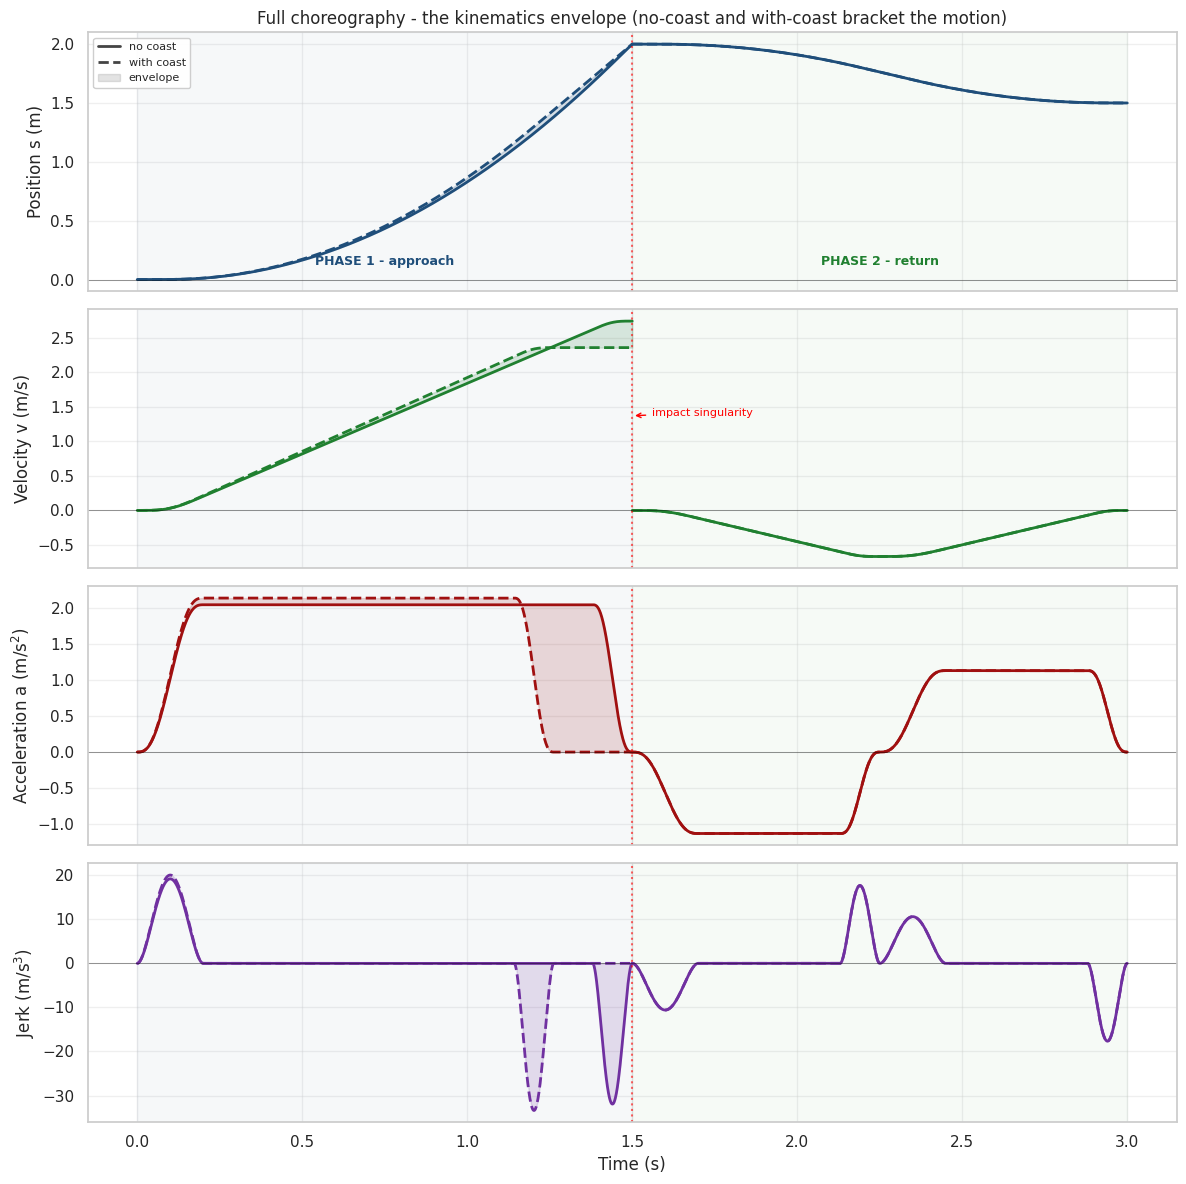

In [10]:
no_coast, with_coast = solve_envelope(CHOREO)
G = 9.80665

# --- envelope comparison table ---
et = Table(show_lines=True, title="[bold]Kinematics envelope - two bracketing solutions[/bold]",
           show_header=True, header_style="bold cyan")
et.add_column("Quantity"); et.add_column("No coast", justify="right")
et.add_column("With coast", justify="right")
et.add_row("Phase-1 coast", f"{no_coast.phase1.t_coast * 1e3:.0f} ms",
           f"{with_coast.phase1.t_coast * 1e3:.0f} ms")
et.add_row("Phase-1 plateau", f"{no_coast.phase1.t_plateau * 1e3:.0f} ms",
           f"{with_coast.phase1.t_plateau * 1e3:.0f} ms")
et.add_row("Closing velocity v_close", f"{no_coast.v_close:.3f} m/s",
           f"{with_coast.v_close:.3f} m/s")
et.add_row("Phase-1 peak acceleration", f"{no_coast.phase1.a_peak / G:.2f} g",
           f"{with_coast.phase1.a_peak / G:.2f} g")
et.add_row("Phase-1 peak jerk", f"{no_coast.phase1.jerk_peak:.1f} m/s^3",
           f"{with_coast.phase1.jerk_peak:.1f} m/s^3")
et.add_row("Phase-2 peak acceleration", f"{no_coast.phase2.a_peak / G:.2f} g",
           f"{with_coast.phase2.a_peak / G:.2f} g")
et.add_row("Impact kinetic energy", f"{no_coast.singularity.kinetic_energy:.0f} J",
           f"{with_coast.singularity.kinetic_energy:.0f} J")
et.add_row("Impact force (Hertzian yield)",
           f"{no_coast.singularity.force_peak / 1e3:.1f} kN",
           f"{with_coast.singularity.force_peak / 1e3:.1f} kN")
console.print(et)

# --- impact force across yield models, both envelope endpoints ---
yt = Table(show_lines=True, title="[bold]Impact singularity - force across yield models (kN)[/bold]",
           show_header=True, header_style="bold cyan")
yt.add_column("Yield model"); yt.add_column("No coast", justify="right")
yt.add_column("With coast", justify="right")
for model in YIELD_FACTORS:
    f_nc = impact_singularity(no_coast.v_close, no_coast.singularity.tau_imp,
                              CHOREO, model).force_peak / 1e3
    f_wc = impact_singularity(with_coast.v_close, with_coast.singularity.tau_imp,
                              CHOREO, model).force_peak / 1e3
    yt.add_row(model, f"{f_nc:.1f}", f"{f_wc:.1f}")
console.print(yt)
console.print(f"[yellow]Envelope: closing velocity {with_coast.v_close:.2f} - "
              f"{no_coast.v_close:.2f} m/s, impact force "
              f"{with_coast.singularity.force_peak / 1e3:.1f} - "
              f"{no_coast.singularity.force_peak / 1e3:.1f} kN (Hertzian). "
              f"The real motion lies between the two.[/yellow]")


def assemble(res):
    """Stitch phase 1 and phase 2 onto the 3 s axis."""
    p1, p2 = res.phase1, res.phase2
    t1 = p1.duration
    return {
        "t": np.concatenate([p1.t, p2.t + t1]),
        "s": np.concatenate([p1.s, p2.s + CHOREO.arc_length]),
        "v": np.concatenate([p1.v, p2.v]),
        "a": np.concatenate([p1.a, p2.a]),
        "jerk": np.concatenate([p1.jerk, p2.jerk]),
        "n1": len(p1.t), "t1": t1,
    }


A, B = assemble(no_coast), assemble(with_coast)
t1, n1 = A["t1"], A["n1"]

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
specs = [("s", "Position s (m)", "#1f4e7a"), ("v", "Velocity v (m/s)", "#208030"),
         ("a", "Acceleration a (m/s$^2$)", "#a01010"),
         ("jerk", "Jerk (m/s$^3$)", "#7030a0")]
for ax, (key, ylab, col) in zip(axes, specs):
    ya, yb = A[key], B[key]
    for sl in (slice(None, n1), slice(n1, None)):
        ax.fill_between(A["t"][sl], ya[sl], yb[sl], color=col, alpha=0.15)
        ax.plot(A["t"][sl], ya[sl], color=col, lw=2)
        ax.plot(B["t"][sl], yb[sl], color=col, lw=2, ls="--")
    ax.axvline(t1, color="red", ls=":", alpha=0.6)
    ax.axhline(0, color="black", lw=0.7, alpha=0.4)
    ax.axvspan(0, t1, color="#1f4e7a", alpha=0.04)
    ax.axvspan(t1, CHOREO.total_time, color="#208030", alpha=0.04)
    ax.set_ylabel(ylab); ax.grid(True, alpha=0.3)
axes[0].plot([], [], color="#444", lw=2, label="no coast")
axes[0].plot([], [], color="#444", lw=2, ls="--", label="with coast")
axes[0].fill_between([], [], [], color="#444", alpha=0.15, label="envelope")
axes[0].legend(loc="upper left", fontsize=8, framealpha=0.95)
axes[0].set_title("Full choreography - the kinematics envelope "
                  "(no-coast and with-coast bracket the motion)")
axes[0].text(t1 / 2, 0.06 * CHOREO.arc_length, "PHASE 1 - approach",
             ha="center", fontsize=9, color="#1f4e7a", fontweight="bold")
axes[0].text((t1 + CHOREO.total_time) / 2, 0.06 * CHOREO.arc_length,
             "PHASE 2 - return", ha="center", fontsize=9, color="#208030",
             fontweight="bold")
axes[1].annotate("impact singularity", xy=(t1, no_coast.v_close * 0.5),
                 textcoords="offset points", xytext=(14, 0), fontsize=8,
                 color="red", arrowprops=dict(arrowstyle="->", color="red"))
axes[3].set_xlabel("Time (s)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01-kinematics-envelope.png", dpi=140, bbox_inches="tight")
plt.show()

## Summary

- The choreography modelling lives in `henryk_simulations.corridor.choreography` - a library module under the corridor submodule, exercised by 30 test guards.  This notebook is a thin client.
- The acceleration is a **structural smooth trapezoid** - give ramp, plateau, let-go ramp, coast - parametrised by its durations.  The give and let-go are literature-pinned (rate of force development).
- The model is **fully determined** once the release standoff is fixed - no free optimisation.  The release standoff is the **envelope variable**.
- The kinematics is reported as an **envelope**: the no-coast solution (propelled to the door) and the with-coast solution (released 2x body thickness back, coasting in) bracket the motion.  Closing velocity 2.4-2.7 m/s, impact force 16-22 kN - the real event lies between.
- The impact is a **decoupled singularity**: phase 1 ends at the closing velocity, the collision is resolved on its own millisecond timeline, phase 2 returns rest-to-rest.
- Forces are downstream: the total impact force combines the impact-force component with Victoria's own acceleration force.